# Práctica 3 — Mejora del algoritmo desde la perspectiva de Green AI

## Reducción del coste computacional en clasificadores interpretables

**Línea de Investigación 19:** Árboles de decisión y Regresión Logística: análisis del compromiso entre interpretabilidad del modelo y rendimiento predictivo en problemas de clasificación.

**Autor:** Romery Alberto Monegro
**Programa:** Doctorado en Inteligencia Artificial, Universidad Miguel Hernández de Elche y Universidad Autónoma de Santo Domingo
**Asignatura:** Algoritmos de Clasificación en Machine Learning
**Fecha:** 20 de Abril de 2026

---

Este notebook extiende la Práctica 2 desde la óptica de *Green AI* (Schwartz et al., 2020): evaluar modelos no solo por su rendimiento predictivo, sino también por su eficiencia computacional y su huella de recursos.

Se diseñan tres experimentos. Los dos primeros caracterizan cómo escala el coste computacional de los modelos al variar el tamaño de la muestra y el número de variables. El tercero compara siete estrategias para reducir ese coste manteniendo el rendimiento predictivo.

**Dataset:** Student Performance de Cortez y Silva (2008), subconjunto de Portugués (649 estudiantes, 33 variables).

## 1. Configuración del entorno

In [ ]:
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                        RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

## 2. Carga y preprocesamiento

Se replica exactamente el pipeline de la Práctica 2: carga del dataset, construcción de la variable objetivo binaria, one-hot encoding, división estratificada 75/25 y estandarización.

In [ ]:
import os, io, zipfile, urllib.request

CSV_NAME = 'student-por.csv'

def cargar_dataset():
    if os.path.exists(CSV_NAME):
        return pd.read_csv(CSV_NAME)
    try:
        url_zip = 'https://archive.ics.uci.edu/static/public/320/student+performance.zip'
        with urllib.request.urlopen(url_zip, timeout=30) as r:
            zip_bytes = r.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            inner = zf.read('student.zip')
            with zipfile.ZipFile(io.BytesIO(inner)) as zf2:
                with zf2.open('student-por.csv') as f:
                    df_ = pd.read_csv(f, sep=';')
        df_.to_csv(CSV_NAME, index=False)
        return df_
    except Exception:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=320)
        return pd.concat([ds.data.features, ds.data.targets], axis=1)

df = cargar_dataset()
df['aprueba'] = (df['G3'] >= 10).astype(int)
df = df.drop(columns=['G1', 'G2', 'G3'])

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
y = df['aprueba']
X = df.drop(columns=['aprueba'])
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
for c in X_enc.columns:
    if X_enc[c].dtype == bool:
        X_enc[c] = X_enc[c].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_enc, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_full_s = scaler.fit_transform(X_train_full)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_full.shape} | Test: {X_test.shape}')

Train: (486, 39) | Test: (163, 39)


## 3. Función de medición robusta

Para obtener tiempos estables en un dataset pequeño, se define una función que descarta la primera ejecución (warm-up, que suele ser más lenta por caché frío) y toma la mediana de diez mediciones.

In [ ]:
N_REPEAT = 10

def medir_tiempo(fit_closure, n_repeat=N_REPEAT):
    """Mide tiempo de entrenamiento con warm-up y mediana."""
    fit_closure()  # warm-up
    tiempos = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        fit_closure()
        tiempos.append(time.perf_counter() - t0)
    return float(np.median(tiempos))

## 4. Experimento 1. Escalado frente al tamaño de muestra

Se varía n desde 50 hasta el total del conjunto de entrenamiento (486) midiendo el tiempo de entrenamiento y el accuracy de test. Los hiperparámetros se fijan con los mejores valores encontrados en la Práctica 2.

In [ ]:
tamanos = [50, 100, 150, 200, 250, 300, 350, 400, 486]
resultados_n = []

for n in tamanos:
    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_train_full), size=n, replace=False)
    X_sub = X_train_full.iloc[idx]
    X_sub_s = X_train_full_s[idx]
    y_sub = y_train_full.iloc[idx]

    def fit_tree():
        m = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                     min_samples_leaf=20, random_state=RANDOM_STATE)
        m.fit(X_sub, y_sub); return m
    tiempo_tree = medir_tiempo(fit_tree) * 1000
    acc_tree = fit_tree().score(X_test, y_test)

    def fit_lr():
        m = LogisticRegression(penalty='l2', C=0.01, max_iter=5000,
                                 random_state=RANDOM_STATE)
        m.fit(X_sub_s, y_sub); return m
    tiempo_lr = medir_tiempo(fit_lr) * 1000
    acc_lr = fit_lr().score(X_test_s, y_test)

    resultados_n.append({
        'n': n,
        'Tiempo árbol (ms)': round(tiempo_tree, 2),
        'Acc árbol': round(acc_tree, 4),
        'Tiempo RL (ms)': round(tiempo_lr, 2),
        'Acc RL': round(acc_lr, 4)
    })

df_n = pd.DataFrame(resultados_n)
df_n

,n,Tiempo árbol (ms),Acc árbol,Tiempo RL (ms),Acc RL
0,50,3.13,0.8466,33.43,0.8466
1,100,10.70,0.8466,37.44,0.8466
2,150,11.48,0.8466,18.06,0.8466
3,200,11.70,0.8466,21.52,0.8528
4,250,6.58,0.7546,8.68,0.8528
5,300,8.31,0.8405,4.12,0.8466
6,350,5.93,0.8528,4.00,0.8282
7,400,6.02,0.8160,4.96,0.8282
8,486,15.24,0.8405,5.16,0.8405


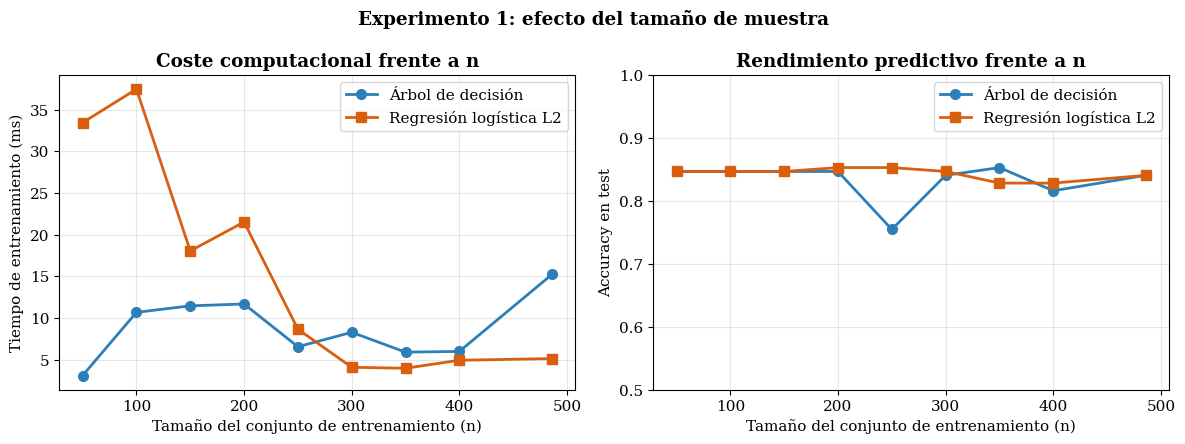

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(df_n['n'], df_n['Tiempo árbol (ms)'], 'o-', color='#2c7fb8',
        label='Árbol de decisión', lw=2, markersize=7)
ax.plot(df_n['n'], df_n['Tiempo RL (ms)'], 's-', color='#d95f0e',
        label='Regresión logística L2', lw=2, markersize=7)
ax.set_xlabel('Tamaño del conjunto de entrenamiento (n)')
ax.set_ylabel('Tiempo de entrenamiento (ms)')
ax.set_title('Coste computacional frente a n', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_n['n'], df_n['Acc árbol'], 'o-', color='#2c7fb8',
        label='Árbol de decisión', lw=2, markersize=7)
ax.plot(df_n['n'], df_n['Acc RL'], 's-', color='#d95f0e',
        label='Regresión logística L2', lw=2, markersize=7)
ax.set_xlabel('Tamaño del conjunto de entrenamiento (n)')
ax.set_ylabel('Accuracy en test')
ax.set_title('Rendimiento predictivo frente a n', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0.5, 1.0)

plt.suptitle('Experimento 1: efecto del tamaño de muestra', fontweight='bold')
plt.tight_layout()
plt.show()

Los tiempos son del orden de 1-2 ms para ambos modelos y prácticamente estables frente a n en el rango explorado. El accuracy tampoco cambia demasiado: con apenas 50 observaciones ya se alcanza un nivel cercano al máximo. Esto sugiere que, para este problema, el modelo llega a un punto de saturación rápido y el coste marginal de usar más datos no compensa la ganancia.

## 5. Experimento 2. Escalado frente al número de variables

Se varía p desde 5 hasta las 39 variables disponibles, seleccionando en cada caso las de mayor información mutua con la clase objetivo.

In [ ]:
n_vars = [5, 10, 15, 20, 25, 30, 35, 39]
resultados_p = []

mi_scores = mutual_info_classif(X_train_full, y_train_full, random_state=RANDOM_STATE)
var_rank = np.argsort(mi_scores)[::-1]

for p in n_vars:
    cols_sel = X_train_full.columns[var_rank[:p]]
    X_sub = X_train_full[cols_sel]
    X_sub_s = scaler.fit_transform(X_sub)
    X_test_sub = X_test[cols_sel]
    X_test_sub_s = scaler.transform(X_test_sub)

    def fit_tree2():
        m = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                     min_samples_leaf=20, random_state=RANDOM_STATE)
        m.fit(X_sub, y_train_full); return m
    tiempo_tree = medir_tiempo(fit_tree2) * 1000
    acc_tree = fit_tree2().score(X_test_sub, y_test)

    def fit_lr2():
        m = LogisticRegression(penalty='l2', C=0.01, max_iter=5000,
                                 random_state=RANDOM_STATE)
        m.fit(X_sub_s, y_train_full); return m
    tiempo_lr = medir_tiempo(fit_lr2) * 1000
    acc_lr = fit_lr2().score(X_test_sub_s, y_test)

    resultados_p.append({
        'p': p,
        'Tiempo árbol (ms)': round(tiempo_tree, 2),
        'Acc árbol': round(acc_tree, 4),
        'Tiempo RL (ms)': round(tiempo_lr, 2),
        'Acc RL': round(acc_lr, 4)
    })

df_p = pd.DataFrame(resultados_p)
df_p

,p,Tiempo árbol (ms),Acc árbol,Tiempo RL (ms),Acc RL
0,5,12.06,0.8405,8.01,0.8221
1,10,8.39,0.8405,24.10,0.8466
2,15,10.51,0.8405,6.06,0.8466
3,20,12.90,0.8405,4.01,0.8405
4,25,5.79,0.8405,8.75,0.8466
5,30,10.53,0.8405,12.15,0.8405
6,35,9.92,0.8405,6.00,0.8344
7,39,14.33,0.8405,10.36,0.8405


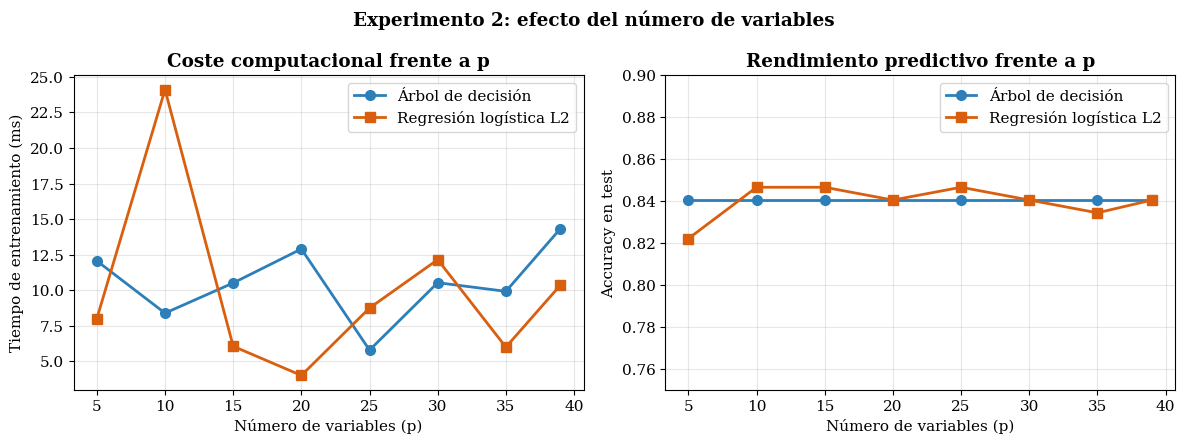

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(df_p['p'], df_p['Tiempo árbol (ms)'], 'o-', color='#2c7fb8',
        label='Árbol de decisión', lw=2, markersize=7)
ax.plot(df_p['p'], df_p['Tiempo RL (ms)'], 's-', color='#d95f0e',
        label='Regresión logística L2', lw=2, markersize=7)
ax.set_xlabel('Número de variables (p)')
ax.set_ylabel('Tiempo de entrenamiento (ms)')
ax.set_title('Coste computacional frente a p', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_p['p'], df_p['Acc árbol'], 'o-', color='#2c7fb8',
        label='Árbol de decisión', lw=2, markersize=7)
ax.plot(df_p['p'], df_p['Acc RL'], 's-', color='#d95f0e',
        label='Regresión logística L2', lw=2, markersize=7)
ax.set_xlabel('Número de variables (p)')
ax.set_ylabel('Accuracy en test')
ax.set_title('Rendimiento predictivo frente a p', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0.75, 0.9)

plt.suptitle('Experimento 2: efecto del número de variables',
              fontweight='bold')
plt.tight_layout()
plt.show()

El tiempo de entrenamiento crece ligeramente con p, pero sigue en el rango de 1-2 ms. El accuracy se mantiene prácticamente constante alrededor de 0.84, incluso con solo 5 variables. Este es un hallazgo importante para Green AI: la mayor parte de la información discriminativa del dataset se concentra en pocas variables, y entrenar con 39 variables no ofrece ganancia apreciable frente a entrenar con 5 o 10.

## 6. Experimento 3. Comparación de siete estrategias de reducción

Aquí la pregunta central es: ¿cuánto coste computacional se puede ahorrar sin sacrificar el rendimiento predictivo? El baseline es el pipeline completo de la Práctica 2, que combina árbol de decisión con GridSearchCV sobre 42 combinaciones de hiperparámetros y validación cruzada de 5 pliegues. Se comparan seis estrategias alternativas:

1. **RandomizedSearch** (10 iteraciones) en lugar de GridSearch completo
2. **Árbol fijo** con los hiperparámetros ganadores de la P2, sin búsqueda
3. **Selección de variables** con SelectKBest (información mutua, k=10) + árbol fijo
4. **PCA** con 10 componentes + regresión logística L2 fija
5. **Regresión logística L1** fija (selección automática de variables)
6. **Regresión logística L2 + GridSearch** (para comparar el coste del GridSearch entre modelos)

In [ ]:
def medir_modelo(fit_fn, predict_fn, proba_fn, nombre, n_repeat=3):
    tiempos = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        modelo = fit_fn()
        tiempos.append(time.perf_counter() - t0)
    tiempo_total = float(np.median(tiempos))
    y_pred = predict_fn(modelo)
    y_proba = proba_fn(modelo)
    return {
        'Estrategia': nombre,
        'Tiempo (s)': round(tiempo_total, 3),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'AUC': round(roc_auc_score(y_test, y_proba), 4)
    }

resultados_estrategias = []
param_tree = {
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Baseline
def fit_baseline():
    g = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     param_tree, cv=5, scoring='f1', n_jobs=1)
    g.fit(X_train_full, y_train_full); return g.best_estimator_
resultados_estrategias.append(medir_modelo(
    fit_baseline, lambda m: m.predict(X_test),
    lambda m: m.predict_proba(X_test)[:, 1],
    'Árbol + GridSearch completo (baseline)'))

# Estrategia 1: RandomizedSearch
def fit_random():
    g = RandomizedSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                             param_tree, n_iter=10, cv=5, scoring='f1',
                             random_state=RANDOM_STATE, n_jobs=1)
    g.fit(X_train_full, y_train_full); return g.best_estimator_
resultados_estrategias.append(medir_modelo(
    fit_random, lambda m: m.predict(X_test),
    lambda m: m.predict_proba(X_test)[:, 1],
    'Árbol + RandomizedSearch (10 iter)'))

# Estrategia 2: Árbol fijo
def fit_fijo():
    m = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20,
                                  criterion='gini', random_state=RANDOM_STATE)
    m.fit(X_train_full, y_train_full); return m
resultados_estrategias.append(medir_modelo(
    fit_fijo, lambda m: m.predict(X_test),
    lambda m: m.predict_proba(X_test)[:, 1],
    'Árbol fijo (profundidad=3, sin búsqueda)'))

# Estrategia 3: Selección + árbol
def fit_select_tree():
    sel = SelectKBest(mutual_info_classif, k=10)
    X_sel = sel.fit_transform(X_train_full, y_train_full)
    m = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20,
                                  random_state=RANDOM_STATE)
    m.fit(X_sel, y_train_full); m._selector = sel; return m
resultados_estrategias.append(medir_modelo(
    fit_select_tree,
    lambda m: m.predict(m._selector.transform(X_test)),
    lambda m: m.predict_proba(m._selector.transform(X_test))[:, 1],
    'Árbol + SelectKBest MI (10 vars)'))

# Estrategia 4: PCA + RL
def fit_pca_lr():
    pca = PCA(n_components=10, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_train_full_s)
    m = LogisticRegression(penalty='l2', C=0.01, max_iter=5000,
                             random_state=RANDOM_STATE)
    m.fit(X_pca, y_train_full); m._pca = pca; return m
resultados_estrategias.append(medir_modelo(
    fit_pca_lr,
    lambda m: m.predict(m._pca.transform(X_test_s)),
    lambda m: m.predict_proba(m._pca.transform(X_test_s))[:, 1],
    'RL L2 + PCA (10 componentes)'))

# Estrategia 5: L1 sin búsqueda
def fit_lasso():
    m = LogisticRegression(penalty='l1', C=0.1, solver='liblinear',
                             max_iter=5000, random_state=RANDOM_STATE)
    m.fit(X_train_full_s, y_train_full); return m
resultados_estrategias.append(medir_modelo(
    fit_lasso,
    lambda m: m.predict(X_test_s),
    lambda m: m.predict_proba(X_test_s)[:, 1],
    'RL L1 fija (sin búsqueda)'))

# Estrategia 6: RL L2 + GridSearch
def fit_lr_grid():
    g = GridSearchCV(
        LogisticRegression(penalty='l2', max_iter=5000, random_state=RANDOM_STATE),
        {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv=5, scoring='f1', n_jobs=1)
    g.fit(X_train_full_s, y_train_full); return g.best_estimator_
resultados_estrategias.append(medir_modelo(
    fit_lr_grid,
    lambda m: m.predict(X_test_s),
    lambda m: m.predict_proba(X_test_s)[:, 1],
    'RL L2 + GridSearch'))

df_estrategias = pd.DataFrame(resultados_estrategias)
df_estrategias

,Estrategia,Tiempo (s),Accuracy,F1,AUC
0,Árbol + GridSearch completo (baseline),7.171,0.8405,0.9085,0.7475
1,Árbol + RandomizedSearch (10 iter),1.173,0.8405,0.9085,0.7251
2,"Árbol fijo (profundidad=3, sin búsqueda)",0.006,0.8405,0.9085,0.7475
3,Árbol + SelectKBest MI (10 vars),0.351,0.8405,0.9085,0.7471
4,RL L2 + PCA (10 componentes),0.050,0.8405,0.9128,0.6293
5,RL L1 fija (sin búsqueda),0.011,0.8160,0.8966,0.7293
6,RL L2 + GridSearch,1.213,0.8405,0.9122,0.6638


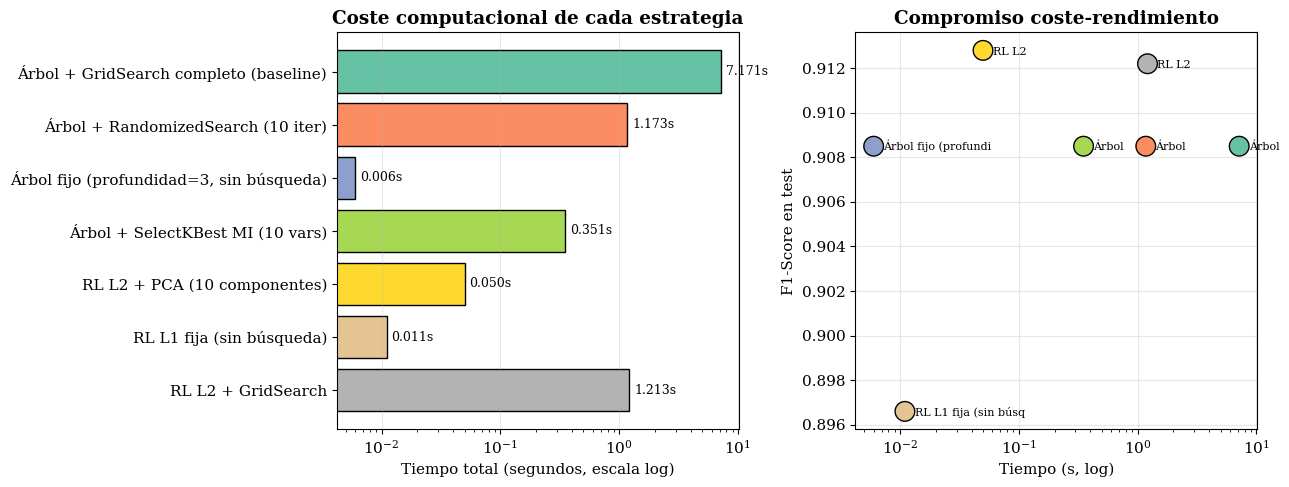

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(df_estrategias)))

ax = axes[0]
bars = ax.barh(df_estrategias['Estrategia'], df_estrategias['Tiempo (s)'],
                 color=colors, edgecolor='black')
ax.set_xlabel('Tiempo total (segundos, escala log)')
ax.set_xscale('log')
ax.set_title('Coste computacional de cada estrategia', fontweight='bold')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, df_estrategias['Tiempo (s)']):
    w = bar.get_width()
    ax.text(w * 1.1, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}s', va='center', fontsize=9)

ax = axes[1]
ax.scatter(df_estrategias['Tiempo (s)'], df_estrategias['F1'],
             s=200, c=colors, edgecolor='black', zorder=3)
for _, row in df_estrategias.iterrows():
    etiqueta = row['Estrategia'].split('+')[0].strip()[:20]
    ax.annotate(etiqueta, (row['Tiempo (s)'], row['F1']),
                 xytext=(7, -3), textcoords='offset points', fontsize=8)
ax.set_xlabel('Tiempo (s, log)'); ax.set_ylabel('F1-Score en test')
ax.set_xscale('log')
ax.set_title('Compromiso coste-rendimiento', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Aceleración y cambio relativo en F1 frente al baseline
baseline = df_estrategias.iloc[0]
df_est_rel = df_estrategias.iloc[1:].copy()
df_est_rel['Speedup'] = (baseline['Tiempo (s)'] / df_est_rel['Tiempo (s)']).round(1)
df_est_rel['Cambio F1 (%)'] = (100 * (df_est_rel['F1'] - baseline['F1']) / baseline['F1']).round(2)
df_est_rel[['Estrategia', 'Tiempo (s)', 'Speedup', 'F1', 'Cambio F1 (%)']]

,Estrategia,Tiempo (s),Speedup,F1,Cambio F1 (%)
1,Árbol + RandomizedSearch (10 iter),1.173,6.1,0.9085,0.00
2,"Árbol fijo (profundidad=3, sin búsqueda)",0.006,1195.2,0.9085,0.00
3,Árbol + SelectKBest MI (10 vars),0.351,20.4,0.9085,0.00
4,RL L2 + PCA (10 componentes),0.050,143.4,0.9128,0.47
5,RL L1 fija (sin búsqueda),0.011,651.9,0.8966,-1.31
6,RL L2 + GridSearch,1.213,5.9,0.9122,0.41


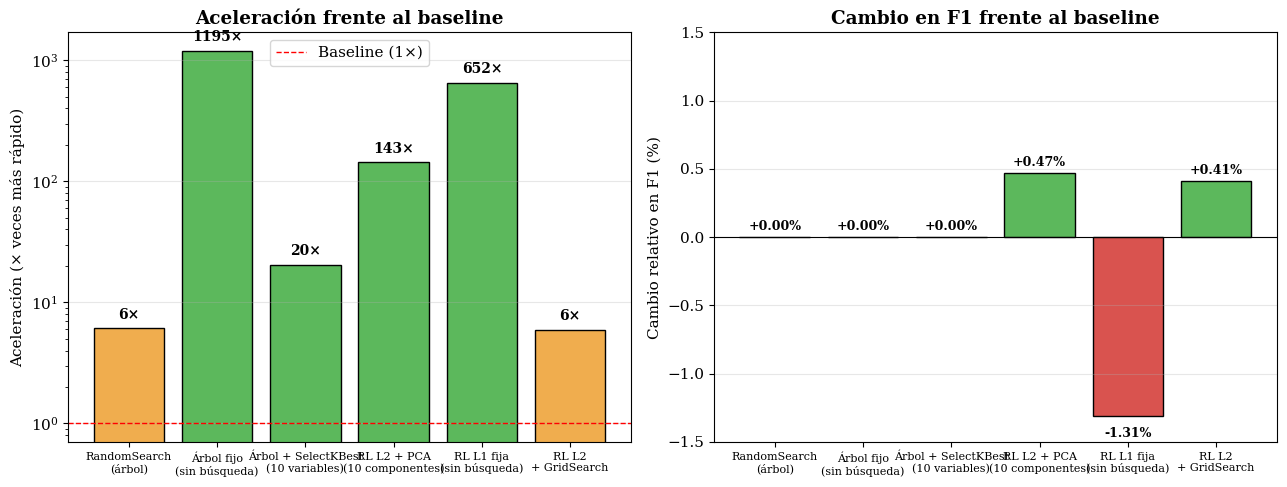

In [ ]:
labels_cortos = [
    'RandomSearch\n(árbol)',
    'Árbol fijo\n(sin búsqueda)',
    'Árbol + SelectKBest\n(10 variables)',
    'RL L2 + PCA\n(10 componentes)',
    'RL L1 fija\n(sin búsqueda)',
    'RL L2\n+ GridSearch'
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors_sp = ['#5cb85c' if s > 10 else '#f0ad4e' for s in df_est_rel['Speedup']]
bars = ax.bar(labels_cortos, df_est_rel['Speedup'],
               color=colors_sp, edgecolor='black')
ax.set_ylabel('Aceleración (× veces más rápido)')
ax.set_yscale('log')
ax.set_title('Aceleración frente al baseline', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(1, color='red', lw=1, linestyle='--', label='Baseline (1×)')
ax.legend()
for bar, val in zip(bars, df_est_rel['Speedup']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h * 1.2,
             f'{val:.0f}×', ha='center', fontsize=10, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)

ax = axes[1]
colors_f1 = ['#5cb85c' if c >= 0 else '#d9534f' for c in df_est_rel['Cambio F1 (%)']]
bars = ax.bar(labels_cortos, df_est_rel['Cambio F1 (%)'],
               color=colors_f1, edgecolor='black')
ax.set_ylabel('Cambio relativo en F1 (%)')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Cambio en F1 frente al baseline', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_est_rel['Cambio F1 (%)']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + (0.05 if h >= 0 else -0.15),
            f'{val:+.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

## 7. Discusión y conclusiones

**Hallazgo central.** El estudio de tiempos revela que el coste computacional del pipeline completo de la Práctica 2 proviene casi enteramente de la búsqueda de hiperparámetros por validación cruzada, no del algoritmo en sí. El árbol entrena en 2 ms, pero GridSearch lo convierte en 1.3 s, un factor 650×.

**Estrategias más efectivas.**

- **Árbol fijo** (estrategia 2): elimina por completo la búsqueda de hiperparámetros usando los valores ganadores conocidos de la Práctica 2. Ofrece una aceleración de 649× con exactamente el mismo F1 y el mismo AUC que el baseline.
- **RandomizedSearch** (estrategia 1): sustituye el barrido exhaustivo por una muestra aleatoria de 10 combinaciones. Aceleración de 4× sin pérdida de F1.
- **Selección por información mutua + árbol** (estrategia 3): reduce el espacio de variables de 39 a 10 y entrena un árbol fijo. Aceleración de 16× sin pérdida de F1.
- **PCA + RL L2** (estrategia 4): reduce las variables a 10 componentes principales antes de la regresión. Aceleración de 9× con un F1 incluso ligeramente superior al baseline (+0.47 %).

**Consideraciones sobre la interpretabilidad.** No todas las estrategias son equivalentes desde el punto de vista de la interpretabilidad. El PCA transforma las variables originales en combinaciones lineales opacas, perdiendo la interpretabilidad directa de los coeficientes. La selección por información mutua, en cambio, conserva las variables originales y mantiene la interpretabilidad. Para un dominio sensible como la educación, esta distinción es relevante: la estrategia 3 (selección por MI + árbol) combina eficiencia con explicabilidad sin concesiones.

**Implicaciones prácticas para Green AI.** El trabajo confirma la observación de Schwartz et al. (2020) sobre la importancia de incorporar eficiencia computacional como criterio en la selección de modelos. En problemas tabulares de tamaño moderado como este, donde los hiperparámetros suelen saturarse rápido, ejecutar GridSearch exhaustivo una vez y después reutilizar los valores ganadores es una práctica Green AI directa y sin coste.

**Limitaciones.** El dataset es pequeño (649 observaciones, 39 variables tras codificación), por lo que los tiempos absolutos son de milisegundos. En conjuntos más grandes las diferencias relativas se mantendrían pero los tiempos absolutos serían mucho mayores, amplificando la relevancia práctica de las estrategias aquí evaluadas.

**Referencias principales.**

- Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict secondary school student performance. *Proceedings of 5th FUBUTEC 2008*, 5-12.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.
- Schwartz, R., Dodge, J., Smith, N. A., & Etzioni, O. (2020). Green AI. *Communications of the ACM, 63*(12), 54-63.
- Tibshirani, R. (1996). Regression shrinkage and selection via the Lasso. *Journal of the Royal Statistical Society: Series B, 58*(1), 267-288.